### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

/usr/lib/python3/dist-packages/paramiko/pkey.py:81: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "cipher": algorithms.TripleDES,
/usr/lib/python3/dist-packages/paramiko/transport.py:254: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "class": algorithms.TripleDES,
/opt/python-ensimag/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/tmp/ipykernel_44234/767131013.py:34: Us

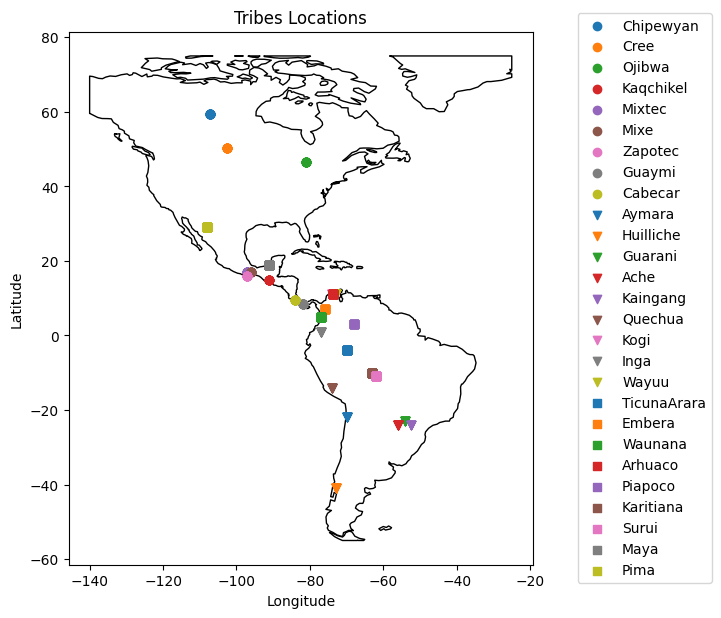

In [1]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

The code does the following:
- The data from the file is loaded
- The attributes lat, long and tribe stored in 3 different arrays
- A geographical dataframe is created using the lat and long from the data: which enables to draw the continents on a map as displayed above
- All of the tribes contained within the dataset are stored in an array based on the unicity of the population
- Each of the tribes are then plotted using their latitude and logitude while changing the marker's shape and color 

## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [2]:
import numpy as np
#Extracting y=longitude
y = df.iloc[:, 7]

#Extracting X: the genetic parameters
X = df.drop(columns=[df.columns[0],df.columns[1], df.columns[2], df.columns[3], df.columns[4], df.columns[5], df.columns[6], df.columns[7] ])
#Calculating beta
#beta = np.linalg.solve(X, y)


Actually this resulted into an error "Last 2 dimensions of the array must be square" given that the matrix X is of shape (494, 5709) and is not a square matrix.
Where as the method numpy.linalg.solve expects a square matrix as first argument given that it solves systems of the form Ax =b whera A is square (n*n)

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [3]:
#Calculating beta
beta = np.linalg.lstsq(X, y)
print(beta)

(array([-0.04005781, -0.01940898,  0.01111306, ..., -0.21729626,
       -0.10210421,  0.01813644], shape=(5709,)), array([], dtype=float64), np.int32(494), array([350.13698149,  61.2802152 ,  56.47103814,  52.56967781,
        51.42502722,  49.17669068,  46.03043029,  44.22192461,
        42.50702788,  40.19391848,  39.47051836,  37.25348648,
        37.00585846,  36.08861574,  35.17549298,  34.19630868,
        33.91155393,  33.25959887,  32.4373858 ,  32.04528856,
        31.98154247,  31.70590905,  31.53732175,  31.11243423,
        30.90088742,  30.84823055,  30.5706054 ,  30.48592164,
        30.34997142,  30.13921597,  29.93319508,  29.80660475,
        29.72177073,  29.65119898,  29.39437467,  29.33821863,
        29.22446147,  29.0348797 ,  28.88322154,  28.79248858,
        28.68861918,  28.55668681,  28.46551384,  28.41355869,
        28.26353612,  28.21226149,  28.0685402 ,  28.02207657,
        27.80229798,  27.75149733,  27.73683265,  27.68979215,
        27.64404213,  27.

Using the numpy.linalg.lstsq funtion, there is no error given that this function does not require X to be square or invertible. It computes the minimum-norm least-squares solution using Singular Value Decomposition (SVD)

 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

In [4]:
from sklearn.linear_model import LinearRegression 
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)

#The estimated coefficients for the linear regression
print(lr.coef_)

[-0.03940988 -0.0245272   0.01089763 ...  0.04804479 -0.08985062
  0.01903025]


The coefficients obtained using sklearn are different from those obtained using np.linalg.lstsq even if it also uses the lstsq method due to the fact that predictors are re-centered that is: from each predictor is subtracted the mean of the feature to which it belongs.
Reasons for doing re-centering:
- To minimize the variation in each of the predictors and improve numerical stability when computing the least-squares solution
- To ensure uniform representation of the features
- Ensures that the intercept is interpretable and will represent the predicted value when all predictors are at their mean value, wher as without recentering it will be the predicted value when preictors are at 0 which is an unrealistic scenario in our dat

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms a high-dimensional dataset into a lower-dimensional representation while retaining as much information (variance) as possible.It enables generally to summarize the information eliminating redundant data or dependent features. It also enables to easily represent data in the case where the features matrix is reduces to 2 features

**Geometric Interpretation:** PCA finds the directions (axes) in the feature space along which the data is most spread out. The first principal component corresponds to the direction of greatest elongation of the data cloud. The second is perpendicular to the first and points in the direction of second greatest spread. PCA can therefore be seen as a rotation of the coordinate system to align with the natural axes of variation in the data.

**Statistical Interpretation:** PCA seeks a new set of uncorrelated variables called principal components (PCs), which are linear combinations of the original features. The first principal component captures the maximum variance in the data, the second captures the maximum remaining variance orthogonal to the first, and so on. Mathematically, this is achieved by computing the eigendecomposition of the covariance matrix of the data

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

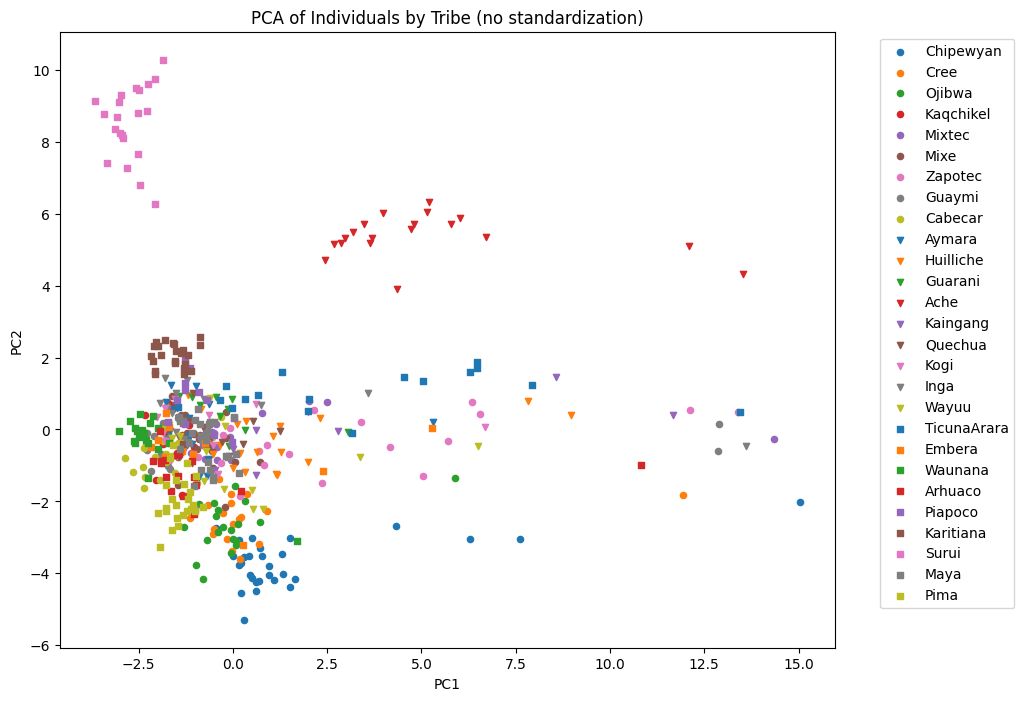

In [5]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

df = pd.read_csv(file_path, sep=r"\s+")

# Select genetic markers (columns from index 8 onwards)
X = df.iloc[:, 8:].astype(float)

# Apply PCA keeping only the first 2 components
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(10, 8))

tribes = df["Pop"]

marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

# Plot each tribe separately with distinct marker and color
for i, tribe in enumerate(tribes.unique()):
    idx = tribes == tribe
    ax.scatter(
        X_reduced[idx, 0],
        X_reduced[idx, 1],
        label=tribe,
        marker=marker_list[i // 9],
        color=colors_list[i % 9],
        s=20
    )

ax.set(
    title="PCA of Individuals by Tribe (no standardization)",
    xlabel="PC1",
    ylabel="PC2"
)

ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


In [6]:
print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))

[0.02050031 0.01518413]
0.03568443899944927


**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

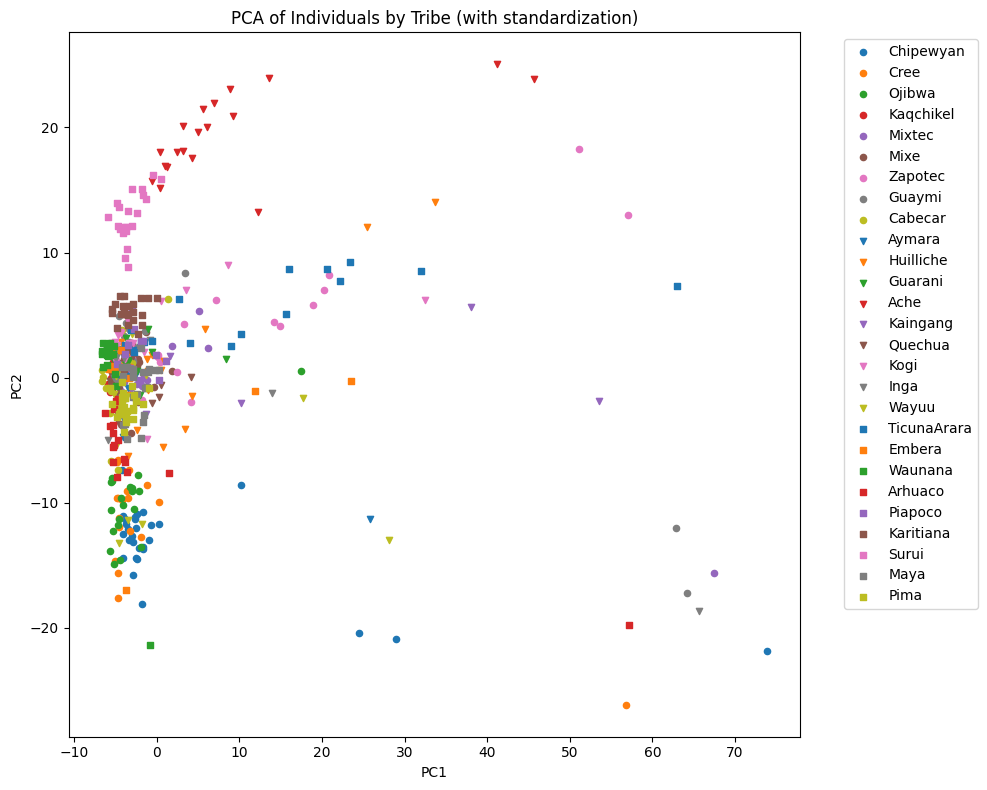

In [7]:
from sklearn.preprocessing import StandardScaler

# Standardize the genetic markers
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Apply PCA on standardized data
pca_std = PCA(n_components=2)
X_reduced_std = pca_std.fit_transform(X_std)

fig, ax = plt.subplots(figsize=(10, 8))

tribes = df["Pop"]

for i, tribe in enumerate(tribes.unique()):
    idx = tribes == tribe
    ax.scatter(
        X_reduced_std[idx, 0],
        X_reduced_std[idx, 1],
        label=tribe,
        marker=marker_list[i // 9],
        color=colors_list[i % 9],
        s=20
    )

ax.set(
    title="PCA of Individuals by Tribe (with standardization)",
    xlabel="PC1",
    ylabel="PC2"
)

ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [8]:
print(pca_std.explained_variance_ratio_)
print(sum(pca_std.explained_variance_ratio_))

[0.02367493 0.01025396]
0.033928895094873186


**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

Standardizing our dat enables us to ensure that all variables contribute equally to PCA given that it relies much on the variance of the variables.
From our dataset above we observed that after using our StandardScaler: the sacle is much larger enabling the tribes to be more spread out instead of been packed like in the first diagram and the central mass is less dense which indicates that standardization has a benefit for this datset by redistributing the variance amongst each predictor and gives equal weight to each of the 5709 markers.


**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

Given that PC1 + PC2 only capture 3.57%, you need substantially more components to represent the genetic data adequately for regression. As such we will need at least a hundred of genetic markers.

## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

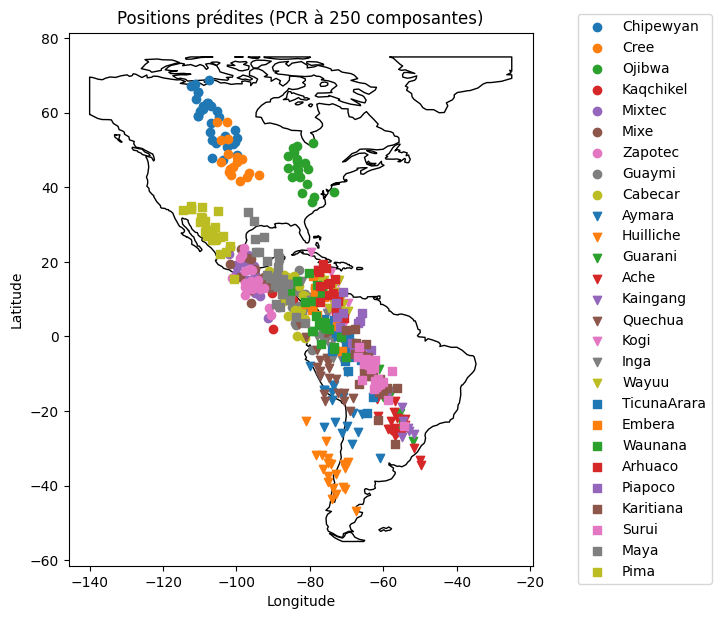

In [9]:
predictors = df.columns[8:]
X = df[predictors].values
y_coords = df[['long', 'lat']].values 

pca = PCA(n_components=250)
X_pca = pca.fit_transform(X)

lr = LinearRegression()
lr.fit(X_pca, y_coords)

y_pred = lr.predict(X_pca)
pred_long = y_pred[:, 0]
pred_lat = y_pred[:, 1]

gdf_pred = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(pred_long, pred_lat))

world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)

world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

for i, tribe in enumerate(gdf_pred['Pop'].unique()):
    members_tribe = gdf_pred[gdf_pred['Pop'] == tribe]
    ax.scatter(members_tribe.geometry.x, members_tribe.geometry.y, 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Positions prédites (PCR à 250 composantes)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

The similarity between the plots show that we can predict with a good precision the coordinates of the groups by using the first 250 PCA axes. These results proves that we can almost entirely find geographical origin of individuals outside the database from its genetic markers. This result demonstrates that even though the number of markers is much larger than the number of samples, the PCA effectively reduces the dimensionality while preserving the essential information needed to predict locations with precision.

However, it is important to note that these results are too optimistic. Since we are testing the model on the same training data used to fit it, the error is artificially low. In a real scenario, we should use a test set to evaluate the true predictive power. Without this separation, the model might be overfitting.

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [10]:
from sklearn.metrics.pairwise import haversine_distances

true_pt = np.radians(np.column_stack((df['lat'].values, df['long'].values)))
pred_pt = np.radians(np.column_stack((pred_lat, pred_long)))

dists = []

for true, pred in zip(true_pt, pred_pt):
    dist_rad = haversine_distances([true, pred])[0, 1]
    dists.append(dist_rad * 6371.0)

dists = np.array(dists)

mean_error_km = np.mean(dists)

print(f"Mean error of the linear regression model : {mean_error_km:.2f} km")

Mean error of the linear regression model : 621.89 km


## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

**(a)** **Cross-validation (CV)** is a resampling procedure used to evaluate a machine learning model by partitioning the data into two parts: a **training set** (used to fit the model) and a **validation set** (used to test it). The dataset is divided into $K$ equal subsets (folds). The model is trained $K$ times, each time using a different fold as the validation set and the remaining $K-1$ folds as the training set. The final performance metric is the average of the results from all $K$ iterations. This procedure prevents overfitting of the model, so it can easily generalize to unseen data.


**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

**(b)** Based on the structure of the dataset, the choice of a cross-validation iterator must account for two specific characteristics: the non-random row order. So we can use **ShuffleSplit or KFold(with shuffling)**.

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [11]:

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, ShuffleSplit, KFold, StratifiedShuffleSplit

predictors = df.columns[8:]
X = df[predictors].values
y = df[['lat', 'long']].values
tribes = df['Pop']

# gkf = GroupKFold(n_splits=10, shuffle=True)

cv = ShuffleSplit(n_splits=10, test_size=0.2)
cv_k =  KFold(n_splits=10, shuffle=True)

n_comp = 250
pipeline = make_pipeline(StandardScaler(), PCA(n_components=n_comp), LinearRegression())

cv_errors_km = []

#for train_idx, text_idx in gkf.split(X, y_coords, groups=tribes):
for train_idx, text_idx in cv_k.split(X):
    X_train, X_test = X[train_idx], X[text_idx]
    y_train, y_test = y_coords[train_idx], y_coords[text_idx]
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)

    
    true_pt_rad = np.radians(y_test)
    pred_pt_rad = np.radians(y_pred)
    
    fold_distances = []
    for true, pred in zip(true_pt_rad, pred_pt_rad):
        dist_rad = haversine_distances([true, pred])[0, 1]
        fold_distances.append(dist_rad * 6371.0) 
    
    cv_errors_km.append(np.mean(fold_distances))

    
mean_cv_error = np.mean(cv_errors_km)


print(f"Résults for PCR with n_components = {n_comp} :")
print(f"Mean error of PCR with cross validation : {mean_cv_error:.2f} km")

Résults for PCR with n_components = 250 :
Mean error of PCR with cross validation : 691.81 km


**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

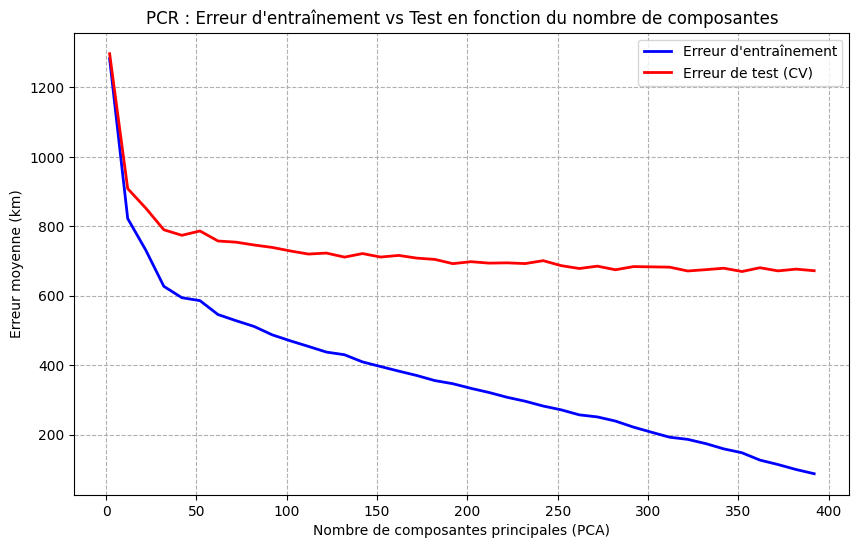

In [12]:
components_range = np.arange(2, 396, 10)

cv_test_errors = []
cv_train_errors = []

cv = ShuffleSplit(n_splits=10, test_size=0.2)
cv_k =  KFold(n_splits=10, shuffle=True)


for n_components in components_range:
    pipeline = make_pipeline(StandardScaler(), PCA(n_components=n_components), LinearRegression())
    fold_test_errors = []
    fold_train_errors = []
    
    for train_idx, text_idx in cv_k.split(X):
        X_train, X_test = X[train_idx], X[text_idx]
        y_train, y_test = y_coords[train_idx], y_coords[text_idx]
        
        pipeline.fit(X_train, y_train)
        
        y_pred_test = pipeline.predict(X_test)
        y_pred_train = pipeline.predict(X_train)
        
        def get_km_error(y_true, y_pred):
            true_rad = np.radians(y_true)
            pred_rad = np.radians(y_pred)
            dists = []
            for t, p in zip(true_rad, pred_rad):
                dist_rad = haversine_distances([t, p])[0, 1]
                dists.append(dist_rad * 6371.0)
            return np.mean(dists)
        
        fold_test_errors.append(get_km_error(y_test, y_pred_test))
        fold_train_errors.append(get_km_error(y_train, y_pred_train))
    
    mean_test = np.mean(fold_test_errors)
    mean_train = np.mean(fold_train_errors)
    
    cv_test_errors.append(mean_test)
    cv_train_errors.append(mean_train)
    
    
plt.figure(figsize=(10, 6))
plt.plot(components_range, cv_train_errors, label='Erreur d\'entraînement', color='blue', lw=2)
plt.plot(components_range, cv_test_errors, label='Erreur de test (CV)', color='red', lw=2)

plt.xlabel('Nombre de composantes principales (PCA)')
plt.ylabel('Erreur moyenne (km)')
plt.title('PCR : Erreur d\'entraînement vs Test en fonction du nombre de composantes')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()
    


In [13]:
results = list(zip(components_range, cv_test_errors, cv_train_errors))
results_sorted = sorted(results, key=lambda x: x[1])

for n, test_err, train_err in results_sorted[:25] :
    print(f"n_components={n:3}: Test = {test_err:8.2f} km | Train = {train_err:8.2f} km")

best_index = np.argmin(cv_test_errors)
best_n = components_range[best_index]
best_test_err = cv_test_errors[best_index]
best_train_err = cv_train_errors[best_index]

print(f"Meilleur nombre de composantes : {best_n}")
print(f"Erreur de test correspondante : {best_test_err:.2f} km")

n_components=352: Test =   669.94 km | Train =   148.00 km
n_components=322: Test =   671.50 km | Train =   186.54 km
n_components=372: Test =   671.79 km | Train =   114.03 km
n_components=392: Test =   672.25 km | Train =    87.60 km
n_components=282: Test =   675.01 km | Train =   239.24 km
n_components=332: Test =   675.30 km | Train =   174.33 km
n_components=382: Test =   676.87 km | Train =    99.69 km
n_components=262: Test =   678.58 km | Train =   257.13 km
n_components=342: Test =   679.43 km | Train =   159.09 km
n_components=362: Test =   680.84 km | Train =   126.77 km
n_components=312: Test =   682.50 km | Train =   192.71 km
n_components=302: Test =   683.37 km | Train =   207.04 km
n_components=292: Test =   684.12 km | Train =   221.76 km
n_components=272: Test =   685.39 km | Train =   251.18 km
n_components=252: Test =   686.80 km | Train =   271.54 km
n_components=192: Test =   692.59 km | Train =   346.81 km
n_components=232: Test =   692.80 km | Train =   296.44 

**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

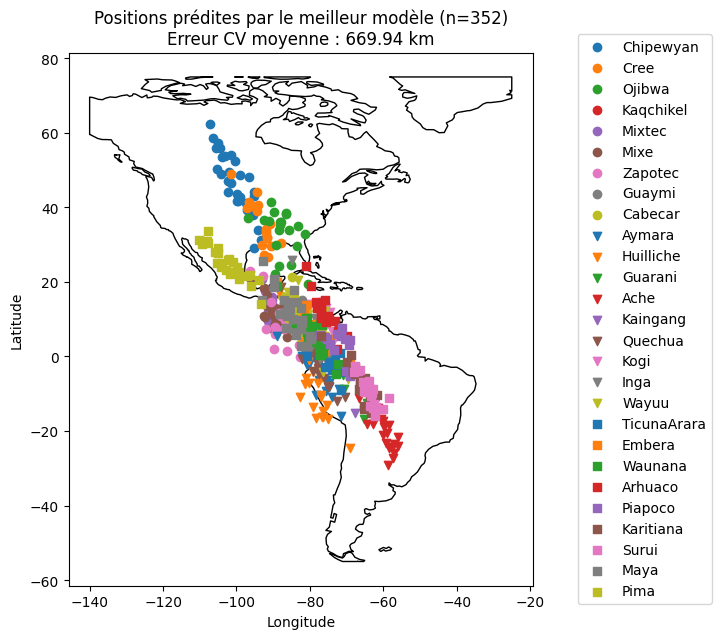

In [34]:
from sklearn.pipeline import Pipeline
y_pred_cv = np.zeros_like(y_coords)
best_pipeline = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=best_n)), ('model', LinearRegression())])

for train_idx, test_idx in cv_k.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_coords[train_idx], y_coords[test_idx]
    
    best_pipeline.fit(X_train, y_train)
    y_pred_cv[test_idx] = best_pipeline.predict(X_test)

gdf_best_pred = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(y_pred_cv[:, 0], y_pred_cv[:, 1]))


fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)

world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

for i, tribe in enumerate(gdf_best_pred['Pop'].unique()):
    members_tribe = gdf_best_pred[gdf_best_pred['Pop'] == tribe]
    ax.scatter(members_tribe.geometry.x, members_tribe.geometry.y, 
               marker=marker_list[(i//9)%3], 
               color=colors_list[i%9], label=tribe)

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title(f'Positions prédites par le meilleur modèle (n={best_n})\nErreur CV moyenne : {best_test_err:.2f} km')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.

**Quality of predictors vs number of factors**
The location of each tribe can be approximated with a good precision with a low number of predictors about 50-250 that shows that the 

In [ ]:
from sklearn.cross_decomposition import PLSRegression

#using PLS instead of PCA
components_range = np.arange(2, 396, 10)

cv_test_errors = []
cv_train_errors = []

cv = ShuffleSplit(n_splits=10, test_size=0.2)
cv_k =  KFold(n_splits=10, shuffle=True)


for n_components in components_range:
    pls = PLSRegression(n_components = best_n)
    fold_test_errors = []
    fold_train_errors = []
    
    for train_idx, text_idx in cv_k.split(X):
        X_train, X_test = X[train_idx], X[text_idx]
        y_train, y_test = y_coords[train_idx], y_coords[text_idx]
        
        pls.fit(X_train, y_train)
        
        y_pred_test = pls.predict(X_test)
        y_pred_train = pls.predict(X_train)
        
        def get_km_error(y_true, y_pred):
            true_rad = np.radians(y_true)
            pred_rad = np.radians(y_pred)
            dists = []
            for t, p in zip(true_rad, pred_rad):
                dist_rad = haversine_distances([t, p])[0, 1]
                dists.append(dist_rad * 6371.0)
            return np.mean(dists)
        
        fold_test_errors.append(get_km_error(y_test, y_pred_test))
        fold_train_errors.append(get_km_error(y_train, y_pred_train))
    
    mean_test = np.mean(fold_test_errors)
    mean_train = np.mean(fold_train_errors)
    
    cv_test_errors.append(mean_test)
    cv_train_errors.append(mean_train)
    
    
plt.figure(figsize=(10, 6))
plt.plot(components_range, cv_train_errors, label='Erreur d\'entraînement', color='blue', lw=2)
plt.plot(components_range, cv_test_errors, label='Erreur de test (CV)', color='red', lw=2)

plt.xlabel('Nombre de composantes principales')
plt.ylabel('Erreur moyenne (km)')
plt.title('PLS : Erreur d\'entraînement vs Test en fonction du nombre de composantes')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()
    


/opt/python-ensimag/lib/python3.12/site-packages/sklearn/cross_decomposition/_pls.py:308: UserWarning: y residual is constant at iteration 99
  warnings.warn(f"y residual is constant at iteration {k}")
/opt/python-ensimag/lib/python3.12/site-packages/sklearn/cross_decomposition/_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
/opt/python-ensimag/lib/python3.12/site-packages/sklearn/cross_decomposition/_pls.py:308: UserWarning: y residual is constant at iteration 175
  warnings.warn(f"y residual is constant at iteration {k}")
/opt/python-ensimag/lib/python3.12/site-packages/sklearn/cross_decomposition/_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
/opt/python-ensimag/lib/python3.12/site-packages/sklearn/cross_decomposition/_pls.py:308: UserWarning: y residual is constant at iteration 316
  warn